## Lilit Poghosyan, CS 251/340A, Machine Learning, Final Project 

Dataset link: https://www.kaggle.com/datasets/swekerr/click-through-rate-prediction

### Introduction

- This project focuses on predicting whether users will click on online advertisements using machine learning classification models. The dataset contains demographic, behavioral, and internet usage information, which were analyzed to identify the factors that influence advertisement clicks.

- Several machine learning models were implemented and compared, including Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting. Data preprocessing, feature engineering, hyperparameter tuning, and model evaluation techniques were applied to improve predictive performance.

- The models were evaluated using metrics such as accuracy, precision, recall, F1-score, confusion matrices, and ROC-AUC curves. The main objective of the project was to determine the most effective model for advertisement click prediction and analyze the most important features influencing user behavior.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc


from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
ads_df = pd.read_csv("ad_10000records.csv")
ads_df.head(10)

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Gender,Country,Timestamp,Clicked on Ad
0,62.26,32,69481.85,172.83,Decentralized real-time circuit,Lisafort,Male,Svalbard & Jan Mayen Islands,6/9/2016 21:43,0
1,41.73,31,61840.26,207.17,Optional full-range projection,West Angelabury,Male,Singapore,1/16/2016 17:56,0
2,44.40,30,57877.15,172.83,Total 5thgeneration standardization,Reyesfurt,Female,Guadeloupe,6/29/2016 10:50,0
3,59.88,28,56180.93,207.17,Balanced empowering success,New Michael,Female,Zambia,6/21/2016 14:32,0
4,49.21,30,54324.73,201.58,Total 5thgeneration standardization,West Richard,Female,Qatar,7/21/2016 10:54,1
5,51.30,26,51463.17,131.68,Focused multi-state workforce,Port Maria,Female,Cameroon,5/15/2016 13:18,0
6,66.08,43,73538.09,136.40,Optimized upward-trending productivity,Port Jeffrey,Male,Turkey,4/3/2016 21:13,1
7,36.08,26,74903.41,228.78,Programmable uniform website,East Kevinbury,Male,French Guiana,3/11/2016 6:49,0
8,46.14,33,43974.49,196.77,Customizable tangible hierarchy,Lake Annashire,Male,Vanuatu,3/24/2016 6:36,0
9,51.65,51,74535.94,188.56,Function-based incremental standardization,Edwardmouth,Female,Cameroon,1/31/2016 5:12,0


In [10]:
ads_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  10000 non-null  float64
 1   Age                       10000 non-null  int64  
 2   Area Income               10000 non-null  float64
 3   Daily Internet Usage      10000 non-null  float64
 4   Ad Topic Line             10000 non-null  object 
 5   City                      10000 non-null  object 
 6   Gender                    10000 non-null  object 
 7   Country                   10000 non-null  object 
 8   Timestamp                 10000 non-null  object 
 9   Clicked on Ad             10000 non-null  int64  
dtypes: float64(3), int64(2), object(5)
memory usage: 781.4+ KB


In [11]:
ads_df.describe()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Clicked on Ad
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,61.660757,35.940100,53840.047721,177.759831,0.491700
std,15.704142,8.572973,13343.708718,40.820951,0.499956
min,32.600000,19.000000,13996.500000,105.220000,0.000000
25%,48.860000,29.000000,44052.302500,140.150000,0.000000
50%,59.590000,35.000000,56180.930000,178.920000,0.000000
75%,76.580000,42.000000,61840.260000,212.670000,1.000000
max,90.970000,60.000000,79332.330000,269.960000,1.000000


In [12]:
ads_df.isnull().sum()

Daily Time Spent on Site    0
Age                         0
Area Income                 0
Daily Internet Usage        0
Ad Topic Line               0
City                        0
Gender                      0
Country                     0
Timestamp                   0
Clicked on Ad               0
dtype: int64

In [6]:
ads_df.ffill(inplace=True)

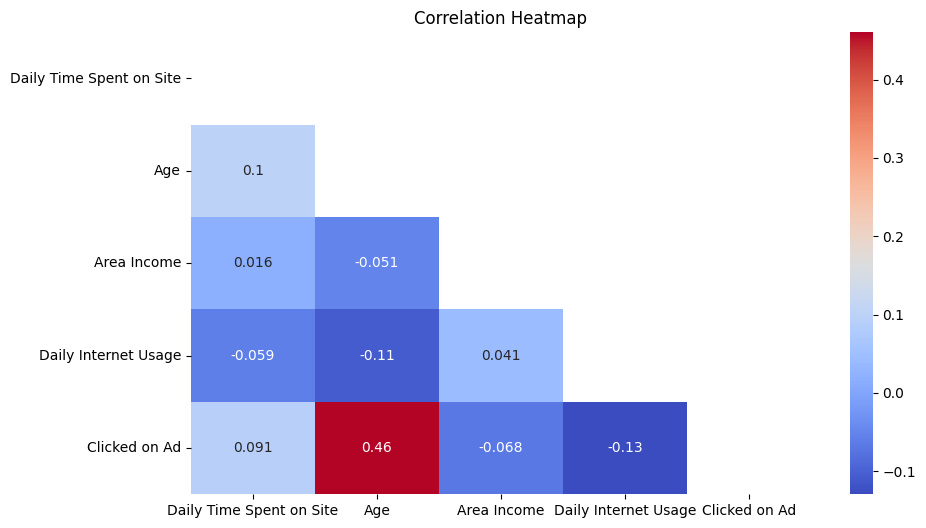

In [14]:
plt.figure(figsize=(10,6))
numeric_data = ads_df.select_dtypes(include=np.number)
correlation_matrix = numeric_data.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap shows the relationships between the numerical features in the dataset. Most variables have weak correlations with each other, indicating that the features are relatively independent.

The strongest positive correlation is between **Age** and **Clicked on Ad** (`0.46`), suggesting that older users were more likely to click on advertisements. **Daily Internet Usage** has a small negative correlation with **Clicked on Ad** (`-0.13`), meaning users with higher internet usage tended to click slightly less on ads.

Other variables such as **Area Income**, **Hour**, **Month**, and **Weekday** show only very weak relationships with the target variable and with each other. Overall, the heatmap indicates that there is no severe multicollinearity among the numerical features, which is beneficial for machine learning modeling.


In [7]:
#Convert Timestamp into useful features
ads_df['Timestamp'] = pd.to_datetime(ads_df['Timestamp'])

ads_df['Hour'] = ads_df['Timestamp'].dt.hour
ads_df['Month'] = ads_df['Timestamp'].dt.month
ads_df['Weekday'] = ads_df['Timestamp'].dt.weekday

ads_df.drop('Timestamp', axis=1, inplace=True)

In [8]:
#Encode Gender
ads_df['Gender'] = ads_df['Gender'].map({
    'Male': 1,
    'Female': 0
})

In [9]:
#One-hot encode Country
ads_df = pd.get_dummies(
    ads_df,
    columns=['Country'],
    drop_first=True
)

In [10]:
#Drop unnecessary text columns
ads_df.drop(
    ['Ad Topic Line', 'City'],
    axis=1,
    inplace=True
)

In [19]:
ads_df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Gender,Clicked on Ad,Hour,Month,Weekday,Country_Albania,...,Country_United States of America,Country_Uruguay,Country_Uzbekistan,Country_Vanuatu,Country_Venezuela,Country_Wallis and Futuna,Country_Western Sahara,Country_Yemen,Country_Zambia,Country_Zimbabwe
0,62.26,32,69481.85,172.83,1,0,21,6,3,False,...,False,False,False,False,False,False,False,False,False,False
1,41.73,31,61840.26,207.17,1,0,17,1,5,False,...,False,False,False,False,False,False,False,False,False,False
2,44.40,30,57877.15,172.83,0,0,10,6,2,False,...,False,False,False,False,False,False,False,False,False,False
3,59.88,28,56180.93,207.17,0,0,14,6,1,False,...,False,False,False,False,False,False,False,False,True,False
4,49.21,30,54324.73,201.58,0,1,10,7,3,False,...,False,False,False,False,False,False,False,False,False,False


In [11]:
#Separate features and target
X = ads_df.drop('Clicked on Ad', axis=1)
y = ads_df['Clicked on Ad']

In [87]:
#scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X)

Random Forest does not require scaling. Random Forest is tree-based and therefore scaling is not mandatory.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Train Random Forest Model

In [16]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [17]:
#prediction
y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.866


In [18]:
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Precision: 0.8731808731808732
Recall: 0.8519269776876268
F1 Score: 0.8624229979466119


Random Forest classifier achieved strong overall performance across all evaluation metrics. 
- The precision score of approximately **87.3%** indicates that most users predicted as clicking on an advertisement actually clicked on it. 
- The recall score of about **85.2%** shows that the model successfully identified a large proportion of the actual ad clicks.
-  Additionally, the F1 score of **86.2%** demonstrates a good balance between precision and recall, indicating that the classifier performs reliably in predicting advertisement click behavior

### Classification Report

In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1014
           1       0.87      0.85      0.86       986

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000



For class 0, the model achieved:

- 86% precision, meaning most users predicted as non-clickers were actually non-clickers.
- 88% recall, indicating the model successfully identified most users who did not click on ads.
- 87% F1-score, showing a strong balance between precision and recall.

For class 1, the model achieved:

- 87% precision, meaning predictions of ad clicks were usually correct.
- 85% recall, showing that the model detected most actual ad clickers.
- 86% F1-score, indicating reliable prediction performance for ad-click behavior.

The macro average and weighted average scores are both approximately 87%, which suggests that the classifier performs consistently across both classes without significant bias toward either category.

### Confusion Matrix

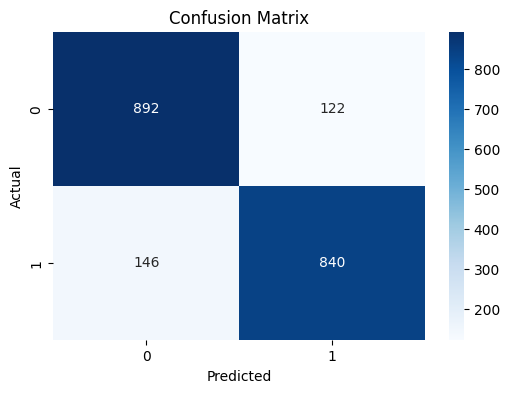

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

The model accurately classified 892 users who did not click on the advertisement and 840 users who clicked on it. However, there were some misclassifications, including 122 false positives and 146 false negatives.

### Feature Importance 

In [21]:
importance_values = rf_model.feature_importances_
feature_labels = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_labels,
    'Importance': importance_values
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

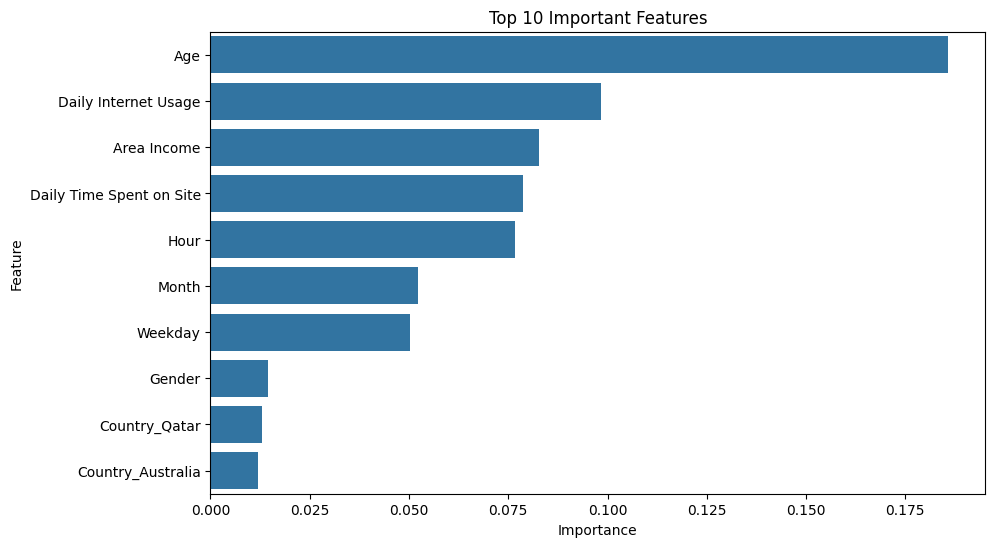

In [22]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

- The feature importance analysis shows that **Age** was the most influential feature which was also highlighted in the correlation analysis. 

- Other highly important features included **Daily Internet Usage**, **Area Income**, and **Daily Time Spent on Site**. 

- Temporal features extracted from the timestamp, such as **Hour**, **Month**, and **Weekday**, also contributed to the model.

- In contrast, **Gender** and individual country variables had relatively low importance in the prediction process.


### Random Forest Hyperparameter Tuning


In [23]:
parameter_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [24]:
rf_model = RandomForestClassifier(
    random_state=42
)

In [25]:
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=parameter_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Grid search completed.")

Grid search completed.


In [26]:
#Clean Results
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

Best Cross Validation Accuracy:
0.845375


In [27]:
best_rf_model = grid_search.best_estimator_

In [28]:
y_pred_tuned = best_rf_model.predict(X_test)

In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1014
           1       0.87      0.85      0.86       986

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000



* Before hyperparameter tuning, the model achieved a precision of **87.3%**, a recall of **85.2%**, and an F1-score of **86.2%**.

* After tuning, the precision became approximately **87%**, while the recall increased to **86%** and the F1-score improved to **87%**.

* The increase in recall from **85.2% to 86%** indicates that the tuned model became slightly better at correctly identifying users who clicked on advertisements.

* The F1-score improvement from **86.2% to 87%** suggests a better balance between precision and recall after optimization.

* Overall, hyperparameter tuning produced a small but positive improvement in the model’s performance and consistency.

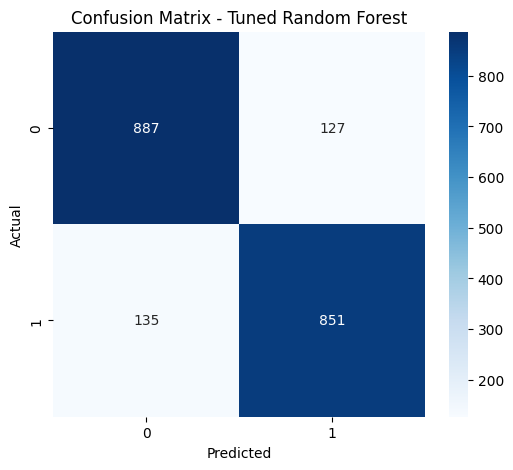

In [30]:
cm_tuned = confusion_matrix(
    y_test,
    y_pred_tuned
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

* Before hyperparameter tuning, the model correctly classified **892** non-clicks and **840** clicks, while producing **122** false positives and **146** false negatives.

* After tuning, the model correctly classified **887** non-clicks and **851** clicks, with **127** false positives and **135** false negatives.

* Although the number of correctly predicted non-clicks decreased slightly from **892 to 887**, the number of correctly predicted clicks increased from **840 to 851**.

* The decrease in false negatives from **146 to 135** indicates that the tuned model became better at identifying users who actually clicked on advertisements.

* However, false positives increased slightly from **122 to 127**, meaning the tuned model occasionally predicted clicks for users who did not actually click.

* Overall, hyperparameter tuning improved the model’s ability to detect actual ad clicks and produced a more balanced classification performance.


#### Feature Importance for Tuned Model

In [31]:
importance_values = best_rf_model.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_values
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

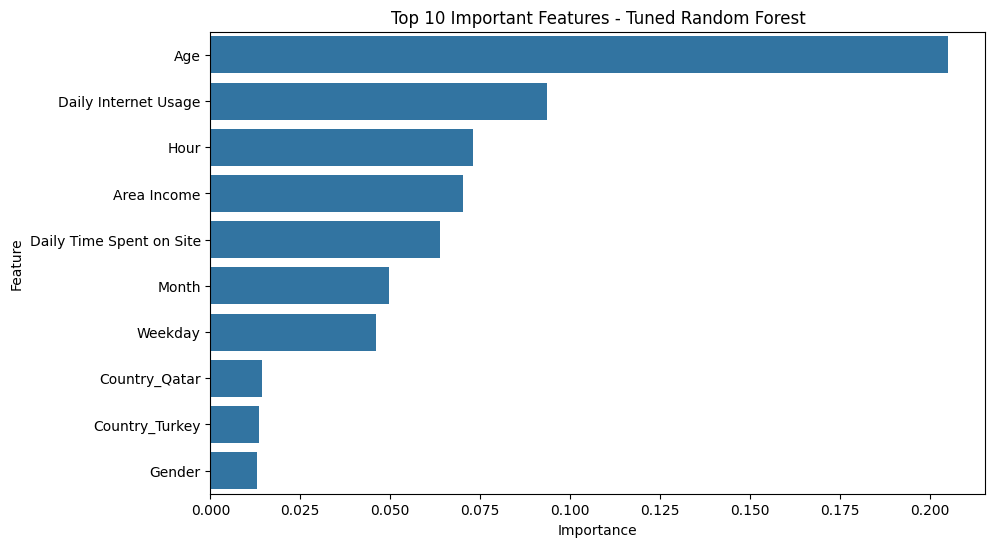

In [32]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df.head(10)
)

plt.title(
    "Top 10 Important Features - Tuned Random Forest"
)

plt.show()

**Random Forest Analysis:**

Random Forest is an ensemble learning model that combines multiple decision trees to improve classification performance and reduce overfitting. Unlike Logistic Regression:

- **Does not require feature scaling** - Random Forest can work effectively with unscaled features because tree-based models are not affected by feature magnitude
- **Uses feature importance** - The model measures how much each feature contributes to reducing impurity across the trees
- **Handles complex relationships** - Capable of capturing non-linear patterns and interactions between features
- **More robust and accurate** - Combining many trees improves generalization and reduces overfitting compared to a single Decision Tree
- **Hyperparameter tuning applied** - GridSearchCV was used to optimize parameters such as `n_estimators`, `max_depth`, `min_samples_split`, and `min_samples_leaf`
- **Higher computational cost** - Training is slower than simpler models like Logistic Regression because multiple trees are created and evaluated

### Random Forest Conclusion

- The tuned Random Forest model demonstrated strong overall classification performance and achieved the best results among the evaluated models. After hyperparameter tuning, the model improved its ability to correctly identify users who clicked on advertisements, as shown by the increase in correctly predicted clicks and the reduction in false negatives.

- Although the number of false positives increased slightly, the overall classification became more balanced and reliable. The feature importance analysis showed that **Age** was the most influential predictor, followed by Daily Internet Usage, Hour, and Area Income.

- Overall, hyperparameter tuning enhanced the model’s predictive capability and helped Random Forest achieve high accuracy, strong generalization, and stable performance on the dataset.

### Comparision with other models
1. Logistic Regression
2. Decision tree
3. Gradient Boosting


### 1. Logistic Regression

In [33]:
# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [34]:
# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)

# Evaluation Metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Logistic Regression Results")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")
print(f"F1 Score: {f1_lr:.4f}")

Logistic Regression Results
Accuracy: 0.8445
Precision: 0.8447
Recall: 0.8387
F1 Score: 0.8417


In [35]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))


Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.85      0.85      1014
           1       0.84      0.84      0.84       986

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000



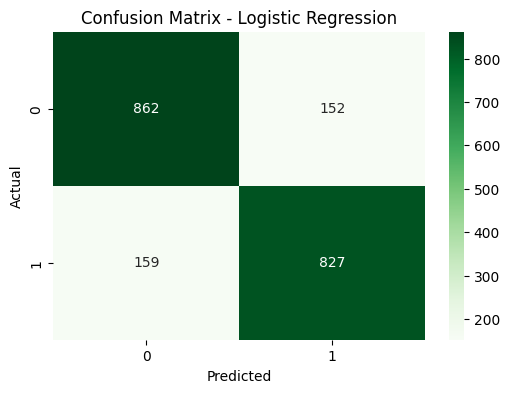

In [36]:
#Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

The confusion matrix shows that the Logistic Regression model performed well in classifying both classes. The model correctly predicted **862** instances of class 0 and **827** instances of class 1. 

There were **152 false positives** and **159 false negatives**, meaning only a relatively small number of observations were misclassified. The balanced distribution of correct predictions and errors indicates that the model performs consistently across both classes and provides stable classification results.

In [37]:
# Feature Importance (using coefficients for Logistic Regression)
coefficients = np.abs(lr_model.coef_[0])
feature_names = X.columns

importance_df_lr = pd.DataFrame({
    'Feature': feature_names,
    'Importance': coefficients
})

importance_df_lr = importance_df_lr.sort_values(
    by='Importance',
    ascending=False
)

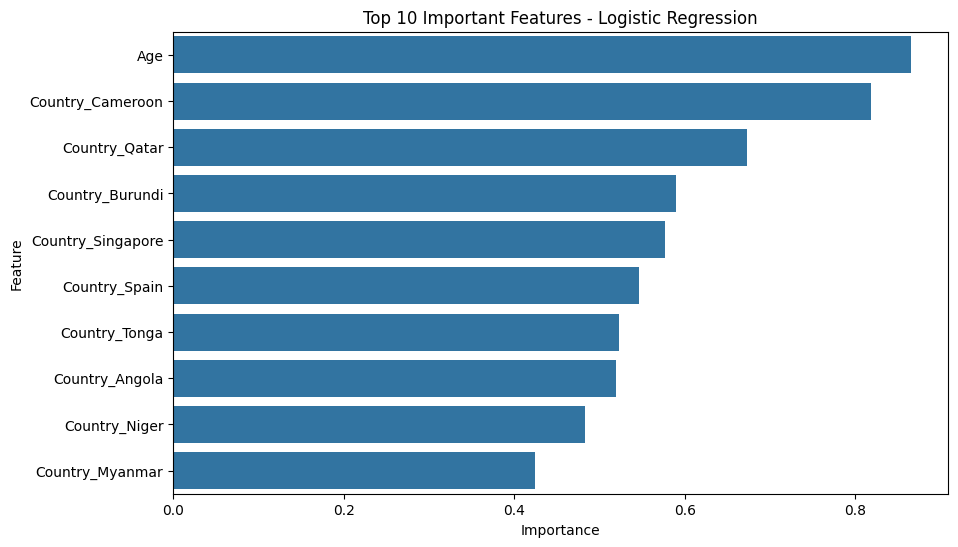

In [38]:
# Visualize Top 10 Features
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df_lr.head(10)
)

plt.title("Top 10 Important Features - Logistic Regression")
plt.show()


**Logistic Regression Analysis:**

Logistic Regression is a linear classifier that uses scaled features to predict binary outcomes. Unlike Random Forest:
- **Requires feature scaling** - Applied StandardScaler to normalize features
- **Uses coefficients instead of feature importance** - The absolute values of coefficients indicate feature impact
- **Interpretability** - Coefficients show the direction and magnitude of feature effects on the target variable
- **Computational efficiency** - Much faster to train and predict compared to ensemble methods

### Logistic Regression vs Tuned Random Forest

The Logistic Regression model achieved an accuracy of **84.45%**, with balanced precision, recall, and F1-score values around **84%**. The confusion matrix also showed that the model correctly classified most observations, with relatively few false predictions. This indicates that Logistic Regression performs reliably and consistently for both classes.

The tuned Random Forest model performed slightly better, achieving an accuracy of approximately **87%** with precision, recall, and F1-score values also around **87%**. Compared to Logistic Regression, the Random Forest model reduced classification errors and provided stronger overall predictive performance.

One advantage of Logistic Regression is that it is simpler and easier to interpret. The feature importance analysis clearly showed that **Age** and several country-related variables were the most influential predictors. In contrast, Random Forest is more powerful because it can capture complex and non-linear relationships in the data, which likely explains its improved performance.


### Decision Tree


In [39]:
# Hyperparameter Tuning for Decision Tree
dt_param_grid = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

dt_model = DecisionTreeClassifier(random_state=42)

dt_grid_search = GridSearchCV(
    estimator=dt_model,
    param_grid=dt_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

dt_grid_search.fit(X_train, y_train)
print("Decision Tree Grid search completed.")

Decision Tree Grid search completed.


In [40]:
# Display Best Parameters
print("Best Parameters:")
print(dt_grid_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(f"{dt_grid_search.best_score_:.4f}")

Best Parameters:
{'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 10}

Best Cross Validation Accuracy:
0.7986


In [41]:
# Get Best Model and Make Predictions
best_dt_model = dt_grid_search.best_estimator_

y_pred_dt = best_dt_model.predict(X_test)

# Evaluation Metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Decision Tree Results (After Tuning)")
print("="*40)
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1 Score: {f1_dt:.4f}")

Decision Tree Results (After Tuning)
Accuracy: 0.7980
Precision: 0.8473
Recall: 0.7201
F1 Score: 0.7785


In [42]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))


Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.87      0.81      1014
           1       0.85      0.72      0.78       986

    accuracy                           0.80      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.80      0.80      0.80      2000



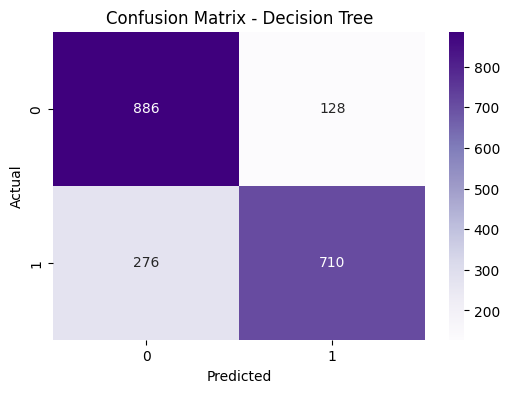

In [43]:
# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

In [44]:
#Feature Importance
dt_importance_values = best_dt_model.feature_importances_

dt_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_importance_values
})

dt_importance_df = dt_importance_df.sort_values(
    by='Importance',
    ascending=False
)

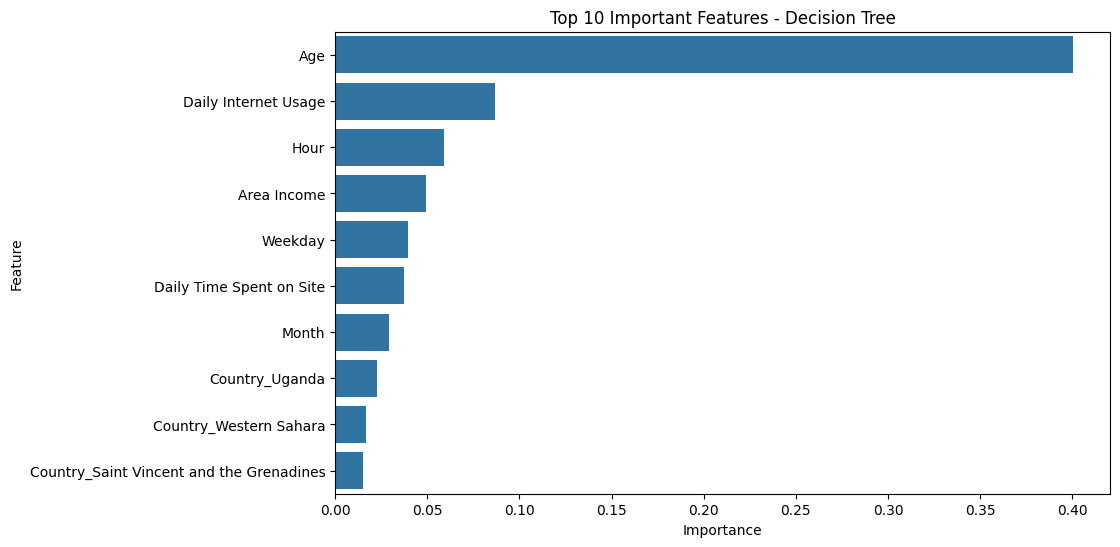

In [45]:
#Visualize Top 10 Features
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=dt_importance_df.head(10)
)

plt.title("Top 10 Important Features - Decision Tree")
plt.show()


**Decision Tree Analysis:**

Decision Tree is a non-parametric model that learns simple decision rules from the data. Key characteristics:
- **No feature scaling required** - Tree-based model is scale-invariant
- **Interpretable** - Decisions are based on feature thresholds in a hierarchical tree structure
- **Hyperparameter tuning** - Applied GridSearchCV with parameters like max_depth, min_samples_split, criterion
- **Feature importance** - Derived from how much each feature reduces impurity at split nodes
- **Risk of overfitting** - Deeper trees can overfit; tuning max_depth and min_samples_leaf mitigates this

The hyperparameter tuning optimizes the tree's complexity to balance accuracy and generalization performance.


## Decision Tree Model

After tuning, the Decision Tree model achieved an accuracy of **79.80%**, with a precision of **84.73%**, recall of **72.01%**, and F1-score of **77.85%**. The model correctly classified most observations, but the lower recall indicates that it missed a larger number of positive cases compared to the other models.

The most important feature was **Age**, followed by Daily Internet Usage, Hour, and Area Income. This shows that both demographic and behavioral features played an important role in the predictions.

Compared to the ensemble models, the Decision Tree performed worse overall. The tuned Random Forest achieved the best results with around **87% accuracy and F1-score**, while Gradient Boosting also showed strong performance. Ensemble methods performed better because they reduce overfitting and capture more complex relationships in the data.

Overall, although the Decision Tree model was easy to interpret and visualize, Random Forest and Gradient Boosting provided more accurate and reliable predictions for this dataset.


### Gradient Boosting


In [46]:
# Hyperparameter Tuning for Gradient Boosting
gb_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

gb_model = GradientBoostingClassifier(random_state=42)

gb_grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=gb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

gb_grid_search.fit(X_train, y_train)
print("Gradient Boosting Grid search completed.")

Gradient Boosting Grid search completed.


In [47]:
# Display Best Parameters
print("Best Parameters:")
print(gb_grid_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(f"{gb_grid_search.best_score_:.4f}")

Best Parameters:
{'learning_rate': 0.2, 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross Validation Accuracy:
0.8497


In [48]:
# Get Best Model and Make Predictions
best_gb_model = gb_grid_search.best_estimator_

y_pred_gb = best_gb_model.predict(X_test)

# Evaluation Metrics
accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)

print("Gradient Boosting Results (After Tuning)")
print("="*40)
print(f"Accuracy: {accuracy_gb:.4f}")
print(f"Precision: {precision_gb:.4f}")
print(f"Recall: {recall_gb:.4f}")
print(f"F1 Score: {f1_gb:.4f}")

Gradient Boosting Results (After Tuning)
Accuracy: 0.8590
Precision: 0.8556
Recall: 0.8590
F1 Score: 0.8573


In [49]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))


Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1014
           1       0.86      0.86      0.86       986

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



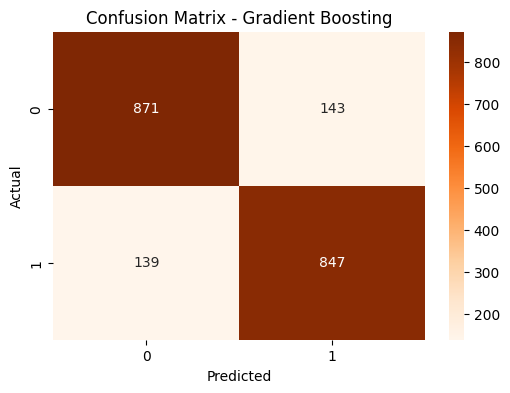

In [50]:
# Confusion Matrix
cm_gb = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_gb,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Gradient Boosting")
plt.show()

In [51]:
# Feature Importance
gb_importance_values = best_gb_model.feature_importances_

gb_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb_importance_values
})


gb_importance_df = gb_importance_df.sort_values(
    by='Importance',
    ascending=False
)

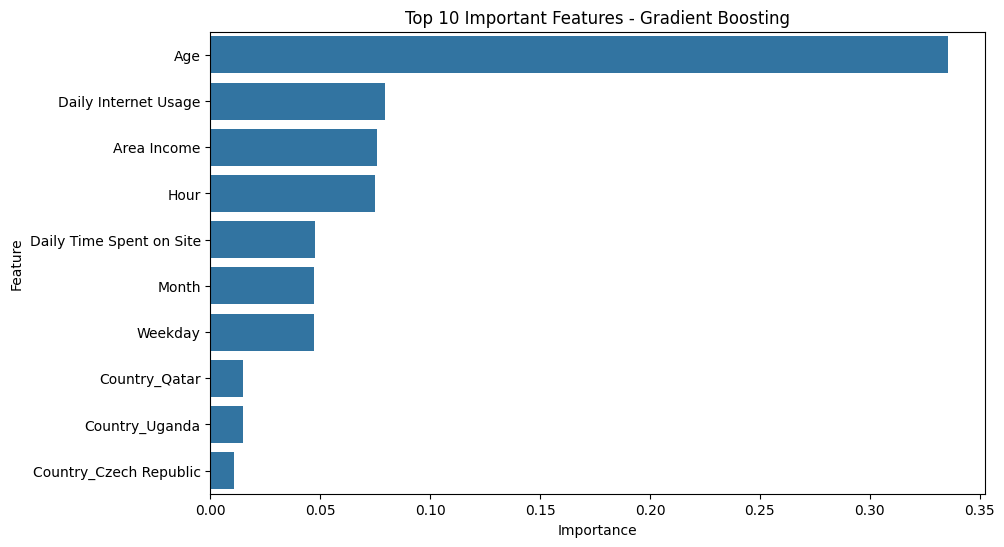

In [52]:
# Visualize Top 10 Features
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=gb_importance_df.head(10)
)

plt.title("Top 10 Important Features - Gradient Boosting")
plt.show()


**Gradient Boosting Analysis:**

Gradient Boosting is an ensemble method that builds trees sequentially, where each tree corrects the errors of the previous ones. Key characteristics:
- **Sequential learning** - Each tree learns from the residuals of the previous trees
- **Learning rate** - Controls how much each tree contributes to the final prediction
- **No feature scaling required** - Tree-based model is scale-invariant
- **Hyperparameter tuning** - Applied GridSearchCV with parameters like n_estimators, learning_rate, max_depth
- **Feature importance** - Derived from how much each feature contributes to reducing loss across all trees
- **High performance** - Often achieves state-of-the-art results but can be computationally expensive
- **Less prone to overfitting** - Through sequential correction and regularization parameters

The hyperparameter tuning optimizes the balance between learning rate and number of estimators to achieve the best performance without overfitting.


## Gradient Boosting Model Conclusion

After tuning, the Gradient Boosting model achieved strong overall performance with an accuracy of **85.9%**, precision of **85.56%**, recall of **85.90%**, and F1-score of **85.73%**. The confusion matrix showed that the model correctly classified most observations while maintaining relatively low false positives and false negatives. These balanced evaluation metrics indicate that the model performed consistently across both classes.

The feature importance analysis showed that **Age** was the most influential feature, followed by Daily Internet Usage, Area Income, and Hour. This suggests that both demographic and behavioral factors played an important role in the prediction process.

Compared to Logistic Regression and Decision Tree, Gradient Boosting achieved better predictive performance.

When compared to the tuned Random Forest model, Gradient Boosting produced very similar results. However, Random Forest slightly outperformed Gradient Boosting with approximately **87% accuracy and F1-score**, making it the best-performing model overall. Despite this, Gradient Boosting still demonstrated strong predictive capability and reliable classification performance.

Overall, the results show that ensemble methods such as Gradient Boosting and Random Forest performed better than the individual models. Gradient Boosting provided accurate and balanced predictions, while Random Forest achieved the highest overall performance on this dataset.

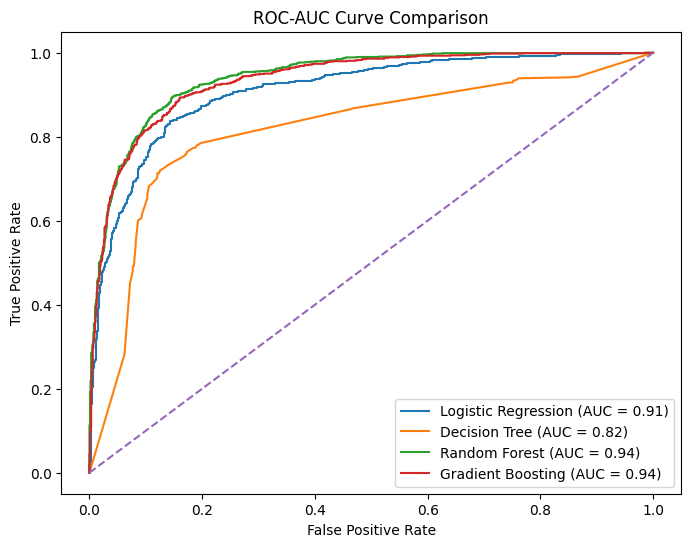

In [53]:
# ROC-AUC Curve Comparison for All Models

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probabilities
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]
dt_probs = best_dt_model.predict_proba(X_test)[:, 1]
rf_probs = best_rf_model.predict_proba(X_test)[:, 1]
gb_probs = best_gb_model.predict_proba(X_test)[:, 1]

# ROC Curves
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_probs)

# AUC Scores
lr_auc = auc(lr_fpr, lr_tpr)
dt_auc = auc(dt_fpr, dt_tpr)
rf_auc = auc(rf_fpr, rf_tpr)
gb_auc = auc(gb_fpr, gb_tpr)

# Plot
plt.figure(figsize=(8,6))

plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.2f})')
plt.plot(dt_fpr, dt_tpr, label=f'Decision Tree (AUC = {dt_auc:.2f})')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.2f})')
plt.plot(gb_fpr, gb_tpr, label=f'Gradient Boosting (AUC = {gb_auc:.2f})')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve Comparison")
plt.legend()

plt.show()

### ROC-AUC Curve Interpretation

The ROC-AUC curves show the classification performance of all evaluated models across different threshold values. A higher AUC score indicates better ability of the model to distinguish between the two classes.

The tuned Random Forest and Gradient Boosting models achieved the highest AUC scores of **0.94**, indicating excellent classification performance and strong ability to separate users who clicked on advertisements from those who did not. Their ROC curves are closest to the top-left corner, which represents ideal classification performance.

Logistic Regression also performed well with an AUC score of **0.91**, showing strong predictive capability despite being a simpler linear model.

The Decision Tree model achieved the lowest AUC score of **0.82**, indicating weaker classification performance compared to the other models. Its ROC curve stays farther from the top-left corner, reflecting lower overall predictive power.

Overall, the ROC-AUC analysis confirms that the ensemble methods, especially Random Forest and Gradient Boosting, provided the best overall performance on the dataset.

## Final Model Comparison

| Model | Accuracy | Precision | Recall | F1-Score |
|---|---|---|---|---|
| Logistic Regression | 84.45% | 84.47% | 83.87% | 84.17% |
| Decision Tree | 79.80% | 84.73% | 72.01% | 77.85% |
| Gradient Boosting | 85.90% | 85.56% | 85.90% | 85.73% |
| Tuned Random Forest | 87.00% | 87.00% | 86.00% | 87.00% |


## Key Findings

- Random Forest achieved the best overall performance and produced the most balanced classification results.
- Gradient Boosting also demonstrated strong predictive capability with high accuracy and stable evaluation metrics.
- Decision Tree showed lower recall and overall performance compared to the ensemble methods.
- Ensemble methods outperformed the individual models by reducing overfitting and improving generalization.
- Across all models, **Age** was consistently identified as the most influential feature in advertisement click prediction.
- Hyperparameter tuning improved the overall performance and reliability of the Random Forest and Gradient Boosting models.


## Overall Conclusion

Overall, the results indicate that ensemble learning methods provided the strongest predictive performance for advertisement click prediction. The tuned Random Forest model achieved the highest overall accuracy and the most reliable classification performance, while Gradient Boosting also produced highly competitive results. Therefore, Random Forest can be considered the most effective model for this dataset.